# Cat breed list

## Introduction

This notebook collects, processes and visualises data about domestic cat breeds sourced from the website **[catbreedslist.com](https://www.catbreedslist.com/all-cat-breeds/)**.

### Data source

| Property | Details |
|---|---|
| **Website** | [www.catbreedslist.com](https://www.catbreedslist.com/all-cat-breeds/) |
| **Pages scraped** | Main page + pages 2–4 (approx. 68 breeds in total) |
| **Scraping method** | Dynamic scraping with **Selenium** + **BeautifulSoup** |

### Collected attributes

For each breed the following fields are extracted:

- **Name** — breed name
- **Origin** — country of origin
- **Lifespan** — lifespan range (years); average computed from min/max
- **Average weight** — weight range (lbs); average computed from min/max
- **Popularity** — ranking position on the website (lower = more popular)
- **Hypoallergenic** — whether the breed is considered hypoallergenic (Yes/No)
- **URL / Image** — links to the breed detail page and thumbnail

### Analysis goals

1. Distribution of breeds by country of origin
2. Relationship between popularity and hypoallergenic status
3. Correlation between average weight and average lifespan
4. Distribution of average lifespan across all breeds

In [1]:
import json
import re
import pandas as pd
import urllib
from urllib.request import Request
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from selenium import webdriver

In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import time

MainPage = "https://www.catbreedslist.com/all-cat-breeds/"
otherUrl = "https://www.catbreedslist.com/all-cat-breeds/page-"

options = Options()
options.add_argument('headless')
browser = webdriver.Chrome(options=options)

pages = []

# Main page
browser.get(MainPage)
time.sleep(2)
bs = BeautifulSoup(browser.page_source, 'html.parser')
pages.append(bs)

# Remaining pages
for page_number in range(2, 5):
    print(f'Fetching page {page_number}')
    currSite = f'{otherUrl}{page_number}.html'
    browser.get(currSite)
    time.sleep(2)
    bs2 = BeautifulSoup(browser.page_source, 'html.parser')
    pages.append(bs2)

browser.quit()

 

Fetching page 2
Fetching page 3
Fetching page 4


In [3]:
pages[3]

<html lang="en-US"><head><link href="https://fonts.googleapis.com/css?family=Archivo:400,500|Arimo:400,500|Bitter:400,500|EB+Garamond:400,500|Lato|Libre+Baskervill|Libre+Franklin:400,500|Lora:400,500|Google+Sans:regular,medium:400,500|Material+Icons|Google+Symbols|Merriweather|Montserrat:400,500|Mukta:400,500|Muli:400,500|Nunito:400,500|Open+Sans:400,500,600|Open+Sans+Condensed:400,600|Oswald:500|Playfair+Display:400,500|Poppins:400,500|Raleway:400,500|Roboto:400,500|Roboto+Condensed:400,500|Roboto+Slab:400,500|Slabo+27px|Source+Sans+Pro|Ubuntu:400,500|Volkhov&amp;display=swap" rel="stylesheet"/>
<meta charset="utf-8"/>
<meta content="ie=edge" http-equiv="x-ua-compatible"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<title>All Cat Breeds - All Types of Cats (78 Breeds)</title>
<meta content="Browse through our list of cat breeds, and find the best cat for you." name="description"/>
<link href="https://www.catbreedslist.com/all-cat-breeds/" rel="canonical"/>

In [4]:
full_cat_data = []
for page in pages:
    full_cat_data += page.find_all(class_ = 'list')

In [5]:
full_cat_data

[<div class="list">
 <div class="list-1"><div class="left"><a href="/all-cat-breeds/ragdoll.html"><img alt="Ragdoll" src="/uploads/cat-pictures/ragdoll-1.jpg"/></a></div><div class="right"><div class="right-t"><p><a href="/all-cat-breeds/ragdoll.html" title="Ragdoll - Price, Personality, Lifespan">Ragdoll</a></p><span>Lifespan: 12-17 years</span></div><div class="right-c"><div class="pop"><p>#1</p><span>Popularity</span></div><div class="hyp"><p>No</p><span>Hypoallergenic</span></div><div class="int"><p>10-20</p><span>Pounds</span></div></div><div class="right-b"><p><b>Origin:</b> United States</p><span><a href="/all-cat-breeds/ragdoll.html">See Details &gt;</a></span></div></div></div>
 <div class="list-2"><p>#1</p><span>Rank</span></div>
 <div class="list-3"><p>Gentle</p><p>Quiet</p><p>Friendly</p><p>Easygoing</p><span>...</span></div>
 <div class="list-4"><p>No</p><span>Hypoallergenic</span></div>
 <div class="list-5"><p>10-20</p><span>Pounds</span></div>
 </div>,
 <div class="list"

In [6]:
cats_data = []
for cat_html in full_cat_data:
    cat = {}
    cat['Name'] = cat_html.find(class_ = 'right-t').find("p").find("a").text.strip()
    cat['Url'] = f"https://www.catbreedslist.com{cat_html.a.get('href')}"
    cat['Img'] = f"https://www.catbreedslist.com{cat_html.img['src']}"
    cat['Lifespan'] = cat_html.find(class_ = 'right-t').find("span").text.split(":")[1].strip()
    cat['Origin'] = cat_html.find(class_ = 'right-b').find("p").text.split(":")[1].strip()
    cat['Popularity'] = cat_html.find(class_ = 'list-2').find("p").text.replace("#", "")

    min_weight = float(cat_html.find(class_ = 'list-5').find("p").text.split("-")[0].strip())
    max_weight = float(cat_html.find(class_ = 'list-5').find("p").text.split("-")[1].strip())

    cat['Average weight'] = (min_weight + max_weight)/2
    cat['Hypoallergenic'] = cat_html.find(class_ = 'list-4').find("p").text

    cats_data.append(cat)


In [7]:
cats_data

[{'Name': 'Ragdoll',
  'Url': 'https://www.catbreedslist.com/all-cat-breeds/ragdoll.html',
  'Img': 'https://www.catbreedslist.com/uploads/cat-pictures/ragdoll-1.jpg',
  'Lifespan': '12-17 years',
  'Origin': 'United States',
  'Popularity': '1',
  'Average weight': 15.0,
  'Hypoallergenic': 'No'},
 {'Name': 'Exotic Shorthair',
  'Url': 'https://www.catbreedslist.com/all-cat-breeds/exotic-shorthair.html',
  'Img': 'https://www.catbreedslist.com/uploads/cat-pictures/exotic-shorthair-1.jpg',
  'Lifespan': '12-15 years',
  'Origin': 'United States',
  'Popularity': '2',
  'Average weight': 11.0,
  'Hypoallergenic': 'No'},
 {'Name': 'British Shorthair',
  'Url': 'https://www.catbreedslist.com/all-cat-breeds/british-shorthair.html',
  'Img': 'https://www.catbreedslist.com/uploads/cat-pictures/british-shorthair-1.jpg',
  'Lifespan': '12-17 years',
  'Origin': 'United Kingdom',
  'Popularity': '3',
  'Average weight': 13.5,
  'Hypoallergenic': 'No'},
 {'Name': 'Persian',
  'Url': 'https://www

In [8]:
for cat in cats_data:
    min_lifespan = pd.to_numeric(cat['Lifespan'].replace('years', '').split('-')[0].strip())
    max_lifespan = pd.to_numeric(cat['Lifespan'].replace('years', '').split('-')[1].strip())

    average_lifespan = (max_lifespan + min_lifespan)/2
    cat['Average lifespan'] = average_lifespan

In [9]:
df = pd.DataFrame.from_dict(cats_data)
df

,Name,Url,Img,Lifespan,Origin,Popularity,Average weight,Hypoallergenic,Average lifespan
0,Ragdoll,https://www.catbreedslist.com/all-cat-breeds/r...,https://www.catbreedslist.com/uploads/cat-pict...,12-17 years,United States,1,15.0,No,14.5
1,Exotic Shorthair,https://www.catbreedslist.com/all-cat-breeds/e...,https://www.catbreedslist.com/uploads/cat-pict...,12-15 years,United States,2,11.0,No,13.5
2,British Shorthair,https://www.catbreedslist.com/all-cat-breeds/b...,https://www.catbreedslist.com/uploads/cat-pict...,12-17 years,United Kingdom,3,13.5,No,14.5
3,Persian,https://www.catbreedslist.com/all-cat-breeds/p...,https://www.catbreedslist.com/uploads/cat-pict...,14-15 years,Iran (Persia),4,11.0,No,14.5
4,Maine Coon,https://www.catbreedslist.com/all-cat-breeds/m...,https://www.catbreedslist.com/uploads/cat-pict...,12-15 years,United States,5,16.5,No,13.5
...,...,...,...,...,...,...,...,...,...
73,Sokoke,https://www.catbreedslist.com/all-cat-breeds/s...,https://www.catbreedslist.com/uploads/cat-pict...,12-15 years,Kenya,-,11.0,No,13.5
74,Minskin,https://www.catbreedslist.com/all-cat-breeds/m...,https://www.catbreedslist.com/uploads/cat-pict...,12-14 years,United States,-,5.0,No,13.0
75,Serengeti cat,https://www.catbreedslist.com/all-cat-breeds/s...,https://www.catbreedslist.com/uploads/cat-pict...,10-15 years,United States,-,11.5,No,12.5
76,Napoleon cat,https://www.catbreedslist.com/all-cat-breeds/n...,https://www.catbreedslist.com/uploads/cat-pict...,12-15 years,United States,-,7.0,No,13.5


Text(0.5, 1.0, 'Number of cat breeds by country of origin')

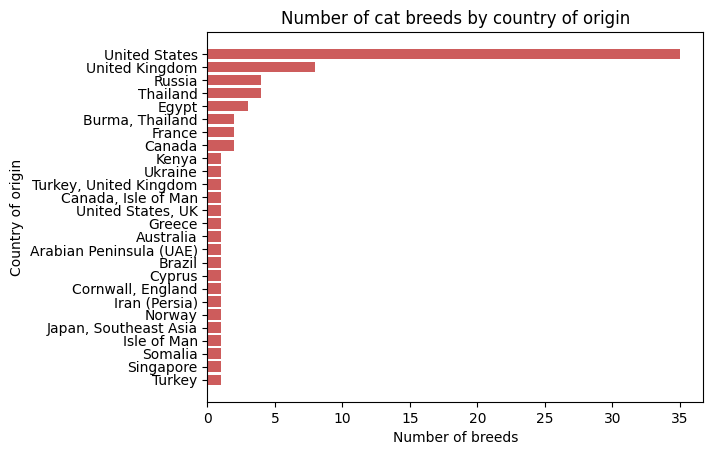

In [10]:
origin_counter = df['Origin'].value_counts().sort_values()

countries = origin_counter.index
counts = origin_counter.values

plt.barh(countries, counts, color='indianred')
plt.xlabel("Number of breeds")
plt.ylabel("Country of origin")
plt.title("Number of cat breeds by country of origin")

C:\Users\Tori\AppData\Local\Temp\ipykernel_8024\3436417542.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Hypoallergenic", y="Popularity", data=dff, palette="Set2")


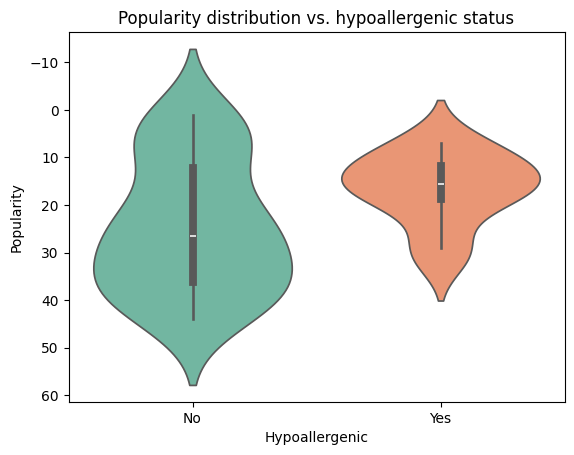

In [14]:
dff = df.copy()
dff['Popularity'] = pd.to_numeric(dff['Popularity'], errors='coerce')
dff = dff.dropna(subset=['Popularity'])

import seaborn as sns

sns.violinplot(x="Hypoallergenic", y="Popularity", data=dff, palette="Set2")
plt.gca().invert_yaxis()
plt.title("Popularity distribution vs. hypoallergenic status")
plt.show()

Text(0.5, 1.0, 'Relationship between average weight and average lifespan')

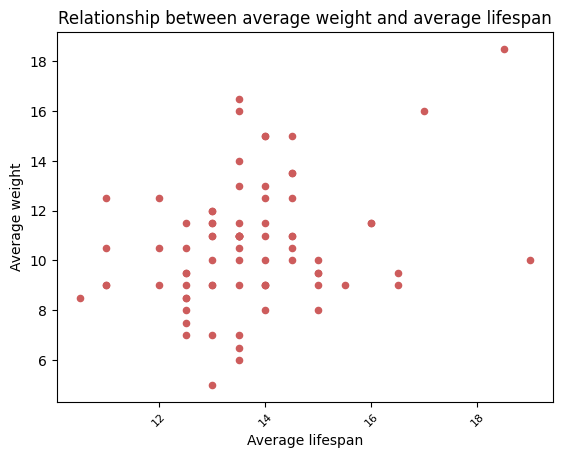

In [16]:
df.plot.scatter(x = 'Average lifespan', y = 'Average weight', c = 'indianred')
plt.xlabel('Average lifespan')
plt.ylabel('Average weight')
plt.xticks(fontsize=8, rotation=45)
plt.title("Relationship between average weight and average lifespan")

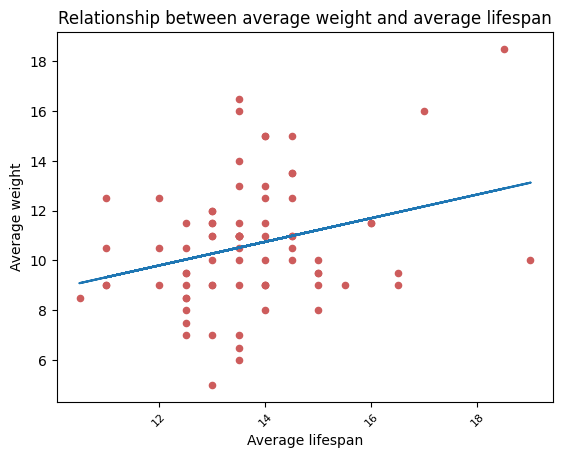

In [17]:
import numpy as np

x = df['Average lifespan']
y = df['Average weight']
priceAndDeposit = np.polyfit(x, y, 1)

polynomial = np.poly1d(priceAndDeposit)

df.plot.scatter(x = 'Average lifespan', y = 'Average weight', c = 'indianred')
plt.xlabel('Average lifespan')
plt.ylabel('Average weight')
plt.xticks(fontsize=8, rotation=45)
plt.title("Relationship between average weight and average lifespan")
plt.plot(x, polynomial(x))

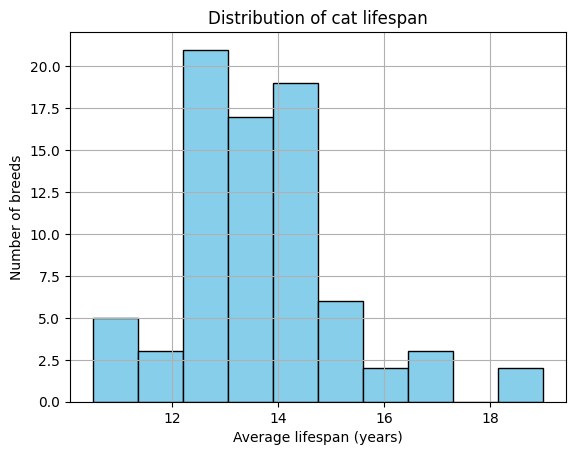

In [18]:
df['Average lifespan'].hist(bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Average lifespan (years)")
plt.ylabel("Number of breeds")
plt.title("Distribution of cat lifespan")
plt.show()
